In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skew, kurtosis
sns.set_theme(style="darkgrid")
print("All imports successful")

All imports successful


In [2]:
import os

# Works whether notebook is run from project root or notebooks/ directory
_cwd = os.getcwd()
_proj_root = _cwd if os.path.exists(os.path.join(_cwd, "README.md")) else os.path.dirname(_cwd)
RESULTS = os.path.join(_proj_root, "results", "phase_1_overview")
os.makedirs(RESULTS, exist_ok=True)
print(f"Results folder: {RESULTS}")

Results folder: c:\Users\kshit\VaR CVaR\results\phase_1_overview


In [3]:
TICKERS = ["SPY", "QQQ", "EFA", "GLD", "TLT", "LQD", "XOM", "VNQ"]

N       = len(TICKERS)
WEIGHTS = np.array([1/N] * N)   # equal weight for now

START_DATE  = "2015-01-01"
END_DATE    = "2024-12-31"
LOOKBACK    = 252    # 1 trading year — used in rolling VaR later
CONF_LEVELS = [0.95, 0.99]

print(f"Tickers  : {TICKERS}")
print(f"Weights  : {WEIGHTS.round(4)}")
print(f"Sum of weights = {WEIGHTS.sum()}")   # must be 1.0
print(f"Date range: {START_DATE}  →  {END_DATE}")

Tickers  : ['SPY', 'QQQ', 'EFA', 'GLD', 'TLT', 'LQD', 'XOM', 'VNQ']
Weights  : [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
Sum of weights = 1.0
Date range: 2015-01-01  →  2024-12-31


In [4]:
raw = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,   # adjusts for splits and dividends
    progress=False,
)["Close"]

# yfinance returns MultiIndex columns when >1 ticker — flatten
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

raw = raw[TICKERS]   # enforce column order

print(f"Shape before dropna : {raw.shape}")
raw.dropna(inplace=True)
print(f"Shape after  dropna : {raw.shape}")
print(f"\nFirst 5 rows:")
raw.head()

Shape before dropna : (2515, 8)
Shape after  dropna : (2515, 8)

First 5 rows:


Ticker,SPY,QQQ,EFA,GLD,TLT,LQD,XOM,VNQ
Date,,,,,,,,
2015-01-02,170.125000,94.665047,43.780636,114.080002,94.086487,81.359978,57.533413,52.549877
2015-01-05,167.052582,93.276474,42.747185,115.800003,95.564491,81.692650,55.959209,52.837494
2015-01-06,165.479141,92.025764,42.262978,117.120003,97.286316,82.025368,55.661701,53.361572
2015-01-07,167.541214,93.212105,42.732731,116.430000,97.094170,82.134003,56.225727,54.179684
2015-01-08,170.514236,94.996140,43.310883,115.940002,95.808319,81.869217,57.161552,54.384182


In [5]:
# raw_data = raw.to_csv("raw_data.csv", index=True)

In [6]:
print("Date range in data:")
print(f"  Start : {raw.index[0].date()}")
print(f"  End   : {raw.index[-1].date()}")
print(f"  Days  : {len(raw)}")

print("\nDescriptive stats on prices:")
raw.describe().round(2)

Date range in data:
  Start : 2015-01-02
  End   : 2024-12-30
  Days  : 2515

Descriptive stats on prices:


Ticker,SPY,QQQ,EFA,GLD,TLT,LQD,XOM,VNQ
count,2515.00,2515.00,2515.00,2515.00,2515.00,2515.00,2515.00,2515.00
mean,309.36,236.40,56.73,150.60,103.15,95.02,64.38,68.01
std,114.07,117.64,10.02,35.21,15.86,9.90,22.75,12.23
min,154.56,89.47,38.09,100.50,74.84,79.11,23.99,45.22
25%,211.59,133.06,48.50,120.12,92.26,87.31,51.79,58.04
50%,272.40,195.21,54.68,144.12,98.11,93.60,55.83,66.55
75%,398.14,326.84,65.30,174.92,115.06,102.49,79.48,76.82
max,597.11,533.92,80.42,257.50,144.90,114.16,119.15,98.08


In [7]:
# log return: r_t = ln(P_t / P_{t-1})
# Why log? Additive across time. Closer to normal. Better for VaR math.

log_returns = np.log(raw / raw.shift(1)).dropna()

print(f"Shape: {log_returns.shape}")
print(f"\nFirst 5 rows of log returns:")
log_returns.head()

Shape: (2514, 8)

First 5 rows of log returns:


Ticker,SPY,QQQ,EFA,GLD,TLT,LQD,XOM,VNQ
Date,,,,,,,,
2015-01-05,-0.018225,-0.014777,-0.023888,0.014965,0.015587,0.004081,-0.027743,0.005458
2015-01-06,-0.009463,-0.013499,-0.011392,0.011334,0.017857,0.004065,-0.005331,0.009870
2015-01-07,0.012384,0.012809,0.011054,-0.005909,-0.001977,0.001324,0.010082,0.015215
2015-01-08,0.017589,0.018959,0.013439,-0.004217,-0.013332,-0.003229,0.016507,0.003767
2015-01-09,-0.008046,-0.006605,-0.004851,0.011321,0.010893,0.002650,-0.001410,0.000470


In [8]:
# Check: no NaN, no Inf, values in a sane range
print("NaN count per asset:")
print(log_returns.isna().sum())

print("\nMin / Max daily return across all assets:")
print(log_returns.min().rename("Min").to_frame().join(
      log_returns.max().rename("Max")))

# Anything outside ±20% in a single day is suspicious
extreme = (log_returns.abs() > 0.20).sum()
print(f"\nDays with |return| > 20%: \n{extreme}")

NaN count per asset:
Ticker
SPY    0
QQQ    0
EFA    0
GLD    0
TLT    0
LQD    0
XOM    0
VNQ    0
dtype: int64

Min / Max daily return across all assets:
             Min       Max
Ticker                    
SPY    -0.115886  0.086731
QQQ    -0.127592  0.081309
EFA    -0.116424  0.081332
GLD    -0.055190  0.047874
TLT    -0.069010  0.072503
LQD    -0.051325  0.071314
XOM    -0.130391  0.119442
VNQ    -0.195136  0.086147

Days with |return| > 20%: 
Ticker
SPY    0
QQQ    0
EFA    0
GLD    0
TLT    0
LQD    0
XOM    0
VNQ    0
dtype: int64


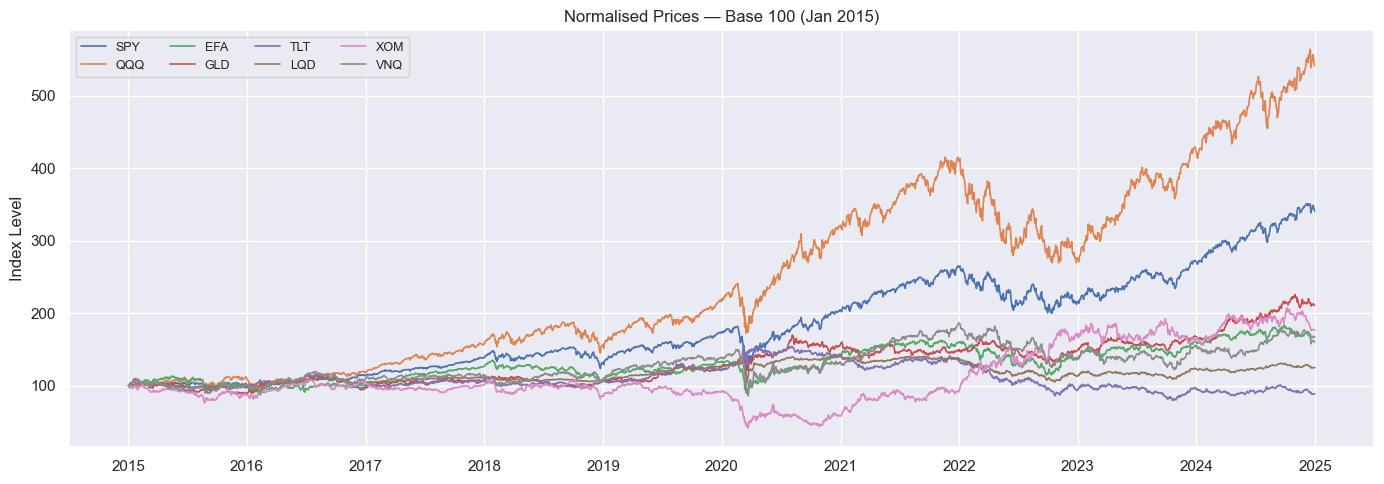

In [9]:
norm_prices = raw / raw.iloc[0] * 100

plt.figure(figsize=(14, 5))
for ticker in TICKERS:
    plt.plot(norm_prices.index, norm_prices[ticker], label=ticker, linewidth=1.2)

plt.title("Normalised Prices — Base 100 (Jan 2015)")
plt.ylabel("Index Level")
plt.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "01_normalised_prices.png"), dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Portfolio return = weighted sum of individual asset log returns
# r_p = w^T * r     (vector dot product)

portfolio_returns = log_returns.dot(WEIGHTS)
portfolio_returns.name = "Portfolio"

print(f"Type  : {type(portfolio_returns)}")
print(f"Shape : {portfolio_returns.shape}")
print(f"\nFirst 5 portfolio daily returns:")
print(portfolio_returns.head())
print(f"\nBasic stats:")
print(portfolio_returns.describe())

Type  : <class 'pandas.core.series.Series'>
Shape : (2514,)

First 5 portfolio daily returns:
Date
2015-01-05   -0.005568
2015-01-06    0.000430
2015-01-07    0.006873
2015-01-08    0.006185
2015-01-09    0.000553
Name: Portfolio, dtype: float64

Basic stats:
count    2514.000000
mean        0.000264
std         0.007376
min        -0.078102
25%        -0.002937
50%         0.000463
75%         0.003792
max         0.062141
Name: Portfolio, dtype: float64


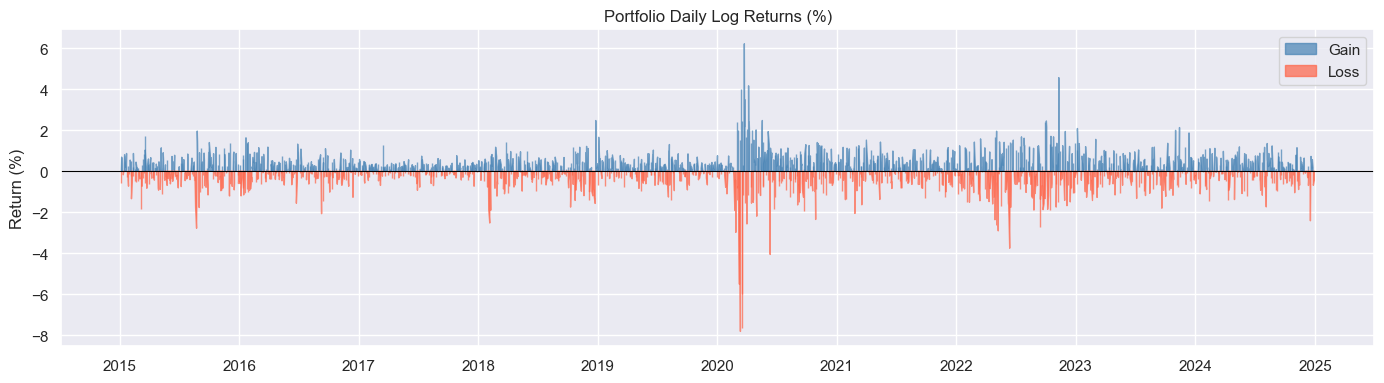

In [11]:
plt.figure(figsize=(14, 4))

plt.fill_between(
    portfolio_returns.index,
    portfolio_returns * 100,
    0,
    where=(portfolio_returns >= 0),
    color="steelblue", alpha=0.7, label="Gain"
)
plt.fill_between(
    portfolio_returns.index,
    portfolio_returns * 100,
    0,
    where=(portfolio_returns < 0),
    color="tomato", alpha=0.7, label="Loss"
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Portfolio Daily Log Returns (%)")
plt.ylabel("Return (%)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "02_daily_returns.png"), dpi=150, bbox_inches="tight")
plt.show()

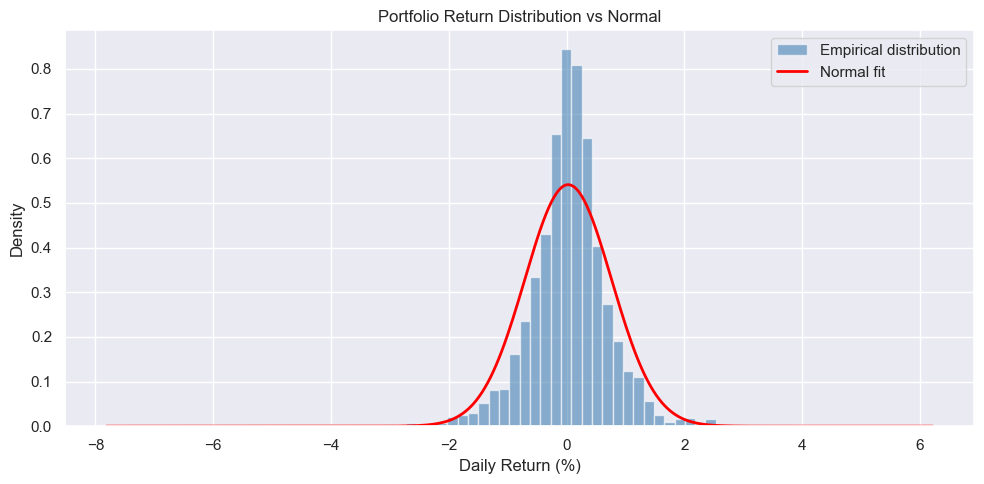

In [12]:
mu    = portfolio_returns.mean()
sigma = portfolio_returns.std()
x     = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 300)

plt.figure(figsize=(10, 5))
plt.hist(portfolio_returns * 100, bins=80, density=True,
         color="steelblue", alpha=0.6, label="Empirical distribution")
plt.plot(x * 100, norm.pdf(x, mu, sigma) / 100,
         color="red", linewidth=2, label="Normal fit")

plt.title("Portfolio Return Distribution vs Normal")
plt.xlabel("Daily Return (%)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "03_return_distribution_vs_normal.png"), dpi=150, bbox_inches="tight")
plt.show()

The empirical bars should be TALLER in the center and at the tails vs the red curve
This is leptokurtosis — fat tails — and it's why parametric VaR (which assumes normal)
will UNDERESTIMATE tail risk. CVaR fixes this

In [13]:
combined = pd.concat([log_returns, portfolio_returns], axis=1)

stats = pd.DataFrame({
    "Ann. Return (%)":   (combined.mean() * 252 * 100).round(2),
    "Ann. Vol (%)":      (combined.std()  * np.sqrt(252) * 100).round(2),
    "Sharpe (rf=0)":     ((combined.mean() / combined.std()) * np.sqrt(252)).round(3),
    "Skewness":          combined.apply(skew).round(3),
    "Excess Kurtosis":   combined.apply(kurtosis).round(3),  # normal = 0
    "Min Daily (%)":     (combined.min() * 100).round(3),
    "Max Daily (%)":     (combined.max() * 100).round(3),
})

print("── Summary Statistics ──────────────────────────────────────────")
stats

# What to look for:
# Excess Kurtosis >> 0 for all assets → fat tails confirmed
# Negative skewness → more extreme down days than up days (typical for equities)
# Portfolio vol < most individual vols → diversification working

── Summary Statistics ──────────────────────────────────────────


,Ann. Return (%),Ann. Vol (%),Sharpe (rf=0),Skewness,Excess Kurtosis,Min Daily (%),Max Daily (%)
SPY,12.29,17.68,0.695,-0.801,13.630,-11.589,8.673
QQQ,16.93,21.88,0.774,-0.554,6.833,-12.759,8.131
EFA,5.12,17.38,0.295,-1.174,14.902,-11.642,8.133
GLD,7.48,14.13,0.530,-0.168,2.778,-5.519,4.787
TLT,-1.20,15.31,-0.078,0.018,4.411,-6.901,7.250
LQD,2.23,8.60,0.259,0.307,28.691,-5.132,7.131
XOM,5.67,27.79,0.204,-0.141,6.539,-13.039,11.944
VNQ,4.71,21.02,0.224,-1.576,25.729,-19.514,8.615
Portfolio,6.66,11.71,0.568,-1.114,16.988,-7.810,6.214


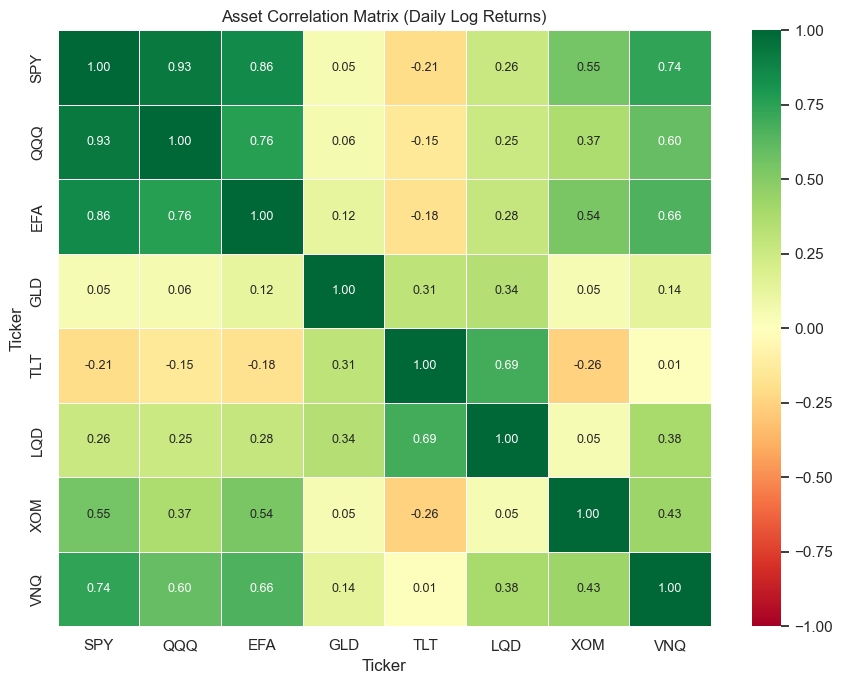

In [14]:
corr = log_returns.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={"size": 9}
)
plt.title("Asset Correlation Matrix (Daily Log Returns)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "04_correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

In [15]:
cov_matrix = log_returns.cov() * 252

print("Annualised Covariance Matrix:")
print(cov_matrix.round(6))

# This matrix is what Phase 2 feeds into:
# - Parametric VaR: portfolio variance = w^T * Σ * w
# - Monte Carlo VaR: Cholesky decomposition of Σ to generate correlated shocks

Annualised Covariance Matrix:
Ticker       SPY       QQQ       EFA       GLD       TLT       LQD       XOM  \
Ticker                                                                         
SPY     0.031267  0.035962  0.026305  0.001180 -0.005665  0.004023  0.027204   
QQQ     0.035962  0.047872  0.028824  0.001756 -0.004894  0.004777  0.022481   
EFA     0.026305  0.028824  0.030215  0.003056 -0.004851  0.004127  0.026043   
GLD     0.001180  0.001756  0.003056  0.019957  0.006756  0.004156  0.001874   
TLT    -0.005665 -0.004894 -0.004851  0.006756  0.023452  0.009067 -0.010857   
LQD     0.004023  0.004777  0.004127  0.004156  0.009067  0.007402  0.001173   
XOM     0.027204  0.022481  0.026043  0.001874 -0.010857  0.001173  0.077247   
VNQ     0.027391  0.027376  0.024256  0.004081  0.000335  0.006939  0.025057   

Ticker       VNQ  
Ticker            
SPY     0.027391  
QQQ     0.027376  
EFA     0.024256  
GLD     0.004081  
TLT     0.000335  
LQD     0.006939  
XOM     0.025057 

In [16]:
port_variance = WEIGHTS @ cov_matrix.values @ WEIGHTS
port_vol      = np.sqrt(port_variance)

print(f"Portfolio Annualised Variance : {port_variance:.6f}")
print(f"Portfolio Annualised Vol      : {port_vol * 100:.3f}%")

# Cross-check against stats table from Cell 11
# Should match "Portfolio" row → Ann. Vol (%)

Portfolio Annualised Variance : 0.013710
Portfolio Annualised Vol      : 11.709%


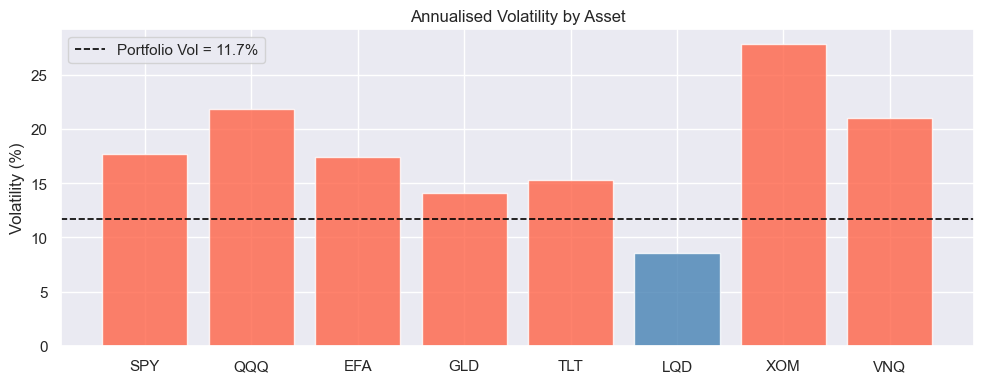

In [17]:
asset_vols = log_returns.std() * np.sqrt(252) * 100

plt.figure(figsize=(10, 4))
colors = ["tomato" if v > port_vol * 100 else "steelblue" for v in asset_vols]
plt.bar(asset_vols.index, asset_vols.values, color=colors, alpha=0.8)
plt.axhline(port_vol * 100, color="black", linestyle="--", linewidth=1.2,
            label=f"Portfolio Vol = {port_vol*100:.1f}%")
plt.title("Annualised Volatility by Asset")
plt.ylabel("Volatility (%)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "05_asset_volatility.png"), dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# This dict is what you pass into every Phase 2 function
# Think of it as your "data layer" contract

portfolio_data = {
    "prices":            raw,
    "log_returns":       log_returns,
    "portfolio_returns": portfolio_returns,
    "weights":           WEIGHTS,
    "tickers":           TICKERS,
    "stats":             stats,
    "cov_matrix":        cov_matrix,
    "corr_matrix":       corr,
    "lookback":          LOOKBACK,
    "conf_levels":       CONF_LEVELS,
}

print("portfolio_data keys:")
for k, v in portfolio_data.items():
    shape = getattr(v, "shape", None) or (len(v) if hasattr(v, "__len__") else v)
    print(f"  {k:25s} → {shape}")

print("\nPhase 1 complete. Ready for Phase 2.")

portfolio_data keys:
  prices                    → (2515, 8)
  log_returns               → (2514, 8)
  portfolio_returns         → (2514,)
  weights                   → (8,)
  tickers                   → 8
  stats                     → (9, 7)
  cov_matrix                → (8, 8)
  corr_matrix               → (8, 8)
  lookback                  → 252
  conf_levels               → 2

Phase 1 complete. Ready for Phase 2.


In [19]:
import pickle

with open("portfolio_data.pkl", "wb") as f:
    pickle.dump(portfolio_data, f)

print("Saved portfolio_data.pkl")

Saved portfolio_data.pkl
